# 02 — Визуализация, линейная алгебра, статистика

**Книга:** «Data Science с нуля» — Джоэл Грасс (2-е издание, 2019)
**Главы:** 3 + 4 + 5
**Источник:** `scratch/visualization.py`, `scratch/linear_algebra.py`, `scratch/statistics.py`

Каждая секция: пояснение → определение → вызов с проверкой → график (если есть).

Графики сохраняются в `_figures/` и **встраиваются в ноутбук** через `IPython.display.Image`. Линейная алгебра (глава 4) дублируется локально для самодостаточности — в оригинале `statistics.py` импортирует из `scratch.linear_algebra`.

**Запуск:** `Kernel → Restart & Run All` (env `mlops`).


## Setup — импорты и путь к фигурам

In [2]:
import math
import os
from collections import Counter
from typing import Callable, List, Tuple

import matplotlib
# 'Agg' — неинтерактивный backend; скрипт работает без дисплея.
# В Jupyter (--execute) matplotlib всё равно встроит графики через savefig + Image.
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from IPython.display import Image, display

FIG_DIR = os.path.join(os.getcwd(), "_figures")
os.makedirs(FIG_DIR, exist_ok=True)
print(f"Фигуры сохраняются в: {FIG_DIR}")


Фигуры сохраняются в: C:\Users\Selecty\Desktop\GIT\MLOps\notebooks\Data Science\_figures


## Глава 3. Визуализация данных

Matplotlib в процедурном стиле (через `pyplot`) — стандарт в DS.

**Правила из главы:**
- линейный график — для временных рядов и непрерывных трендов
- `bar` — для сравнения дискретных категорий
- гистограмма — для распределения ОДНОЙ числовой переменной
- `scatter` — для поиска связей между ДВУМЯ переменными
- ⚠️ НЕ обрезай ось Y с нулём — это обман
- ⚠️ Сравнивай оси (`plt.axis("equal")`), если шкалы должны быть одинаковыми


### 3.1. Линейный график — ВВП по годам

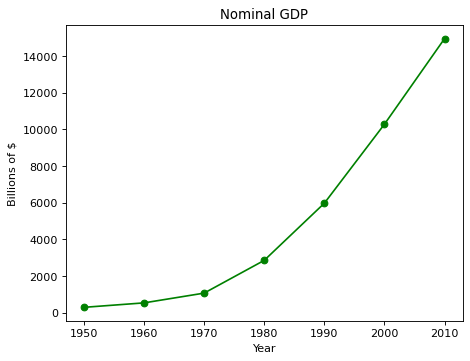

In [4]:
years = [1950, 1960, 1970, 1980, 1990, 2000, 2010]
gdp = [300.2, 543.3, 1075.9, 2862.5, 5979.6, 10289.7, 14958.3]

plt.plot(years, gdp, color="green", marker="o", linestyle="solid")
plt.title("Nominal GDP")
plt.ylabel("Billions of $")
plt.xlabel("Year")

fpath = os.path.join(FIG_DIR, "viz_gdp.png")
plt.savefig(fpath, dpi=80, bbox_inches="tight")
plt.gca().clear()
display(Image(filename=fpath))


### 3.2. Столбчатая диаграмма — Оскары за фильмы

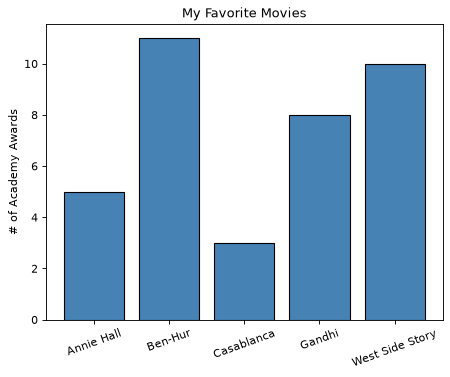

In [3]:
movies = ["Annie Hall", "Ben-Hur", "Casablanca", "Gandhi", "West Side Story"]
num_oscars = [5, 11, 3, 8, 10]

plt.bar(range(len(movies)), num_oscars, color="steelblue", edgecolor="black")
plt.title("My Favorite Movies")
plt.ylabel("# of Academy Awards")
plt.xticks(range(len(movies)), movies, rotation=20)

fpath = os.path.join(FIG_DIR, "viz_movies.png")
plt.savefig(fpath, dpi=80, bbox_inches="tight")
plt.gca().clear()
display(Image(filename=fpath))


### 3.3. Гистограмма через бакетизацию — оценки за экзамен

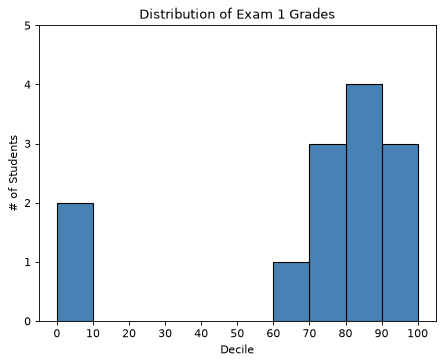

Гистограмма: {80: 4, 90: 3, 70: 3, 0: 2, 60: 1}


In [4]:
grades = [83, 95, 91, 87, 70, 0, 85, 82, 100, 67, 73, 77, 0]

# Бакетизация: целые десятки, но 100 -> к 90-м
histogram = Counter(min(grade // 10 * 10, 90) for grade in grades)

plt.bar(
    [x + 5 for x in histogram.keys()],
    histogram.values(),
    10,
    edgecolor=(0, 0, 0),
    color="steelblue",
)
plt.axis([-5, 105, 0, 5])
plt.xticks([10 * i for i in range(11)])
plt.xlabel("Decile")
plt.ylabel("# of Students")
plt.title("Distribution of Exam 1 Grades")

fpath = os.path.join(FIG_DIR, "viz_grades.png")
plt.savefig(fpath, dpi=80, bbox_inches="tight")
plt.gca().clear()
display(Image(filename=fpath))

print(f"Гистограмма: {dict(histogram)}")


### 3.4. ⚠️ Манипулятивная ось Y (антипаттерн!)

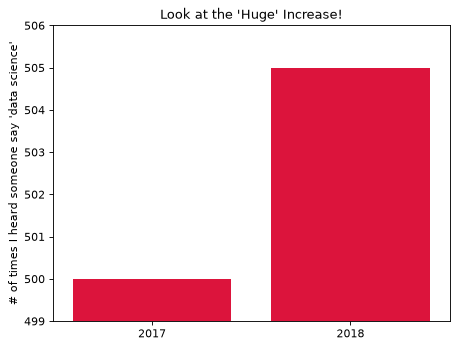

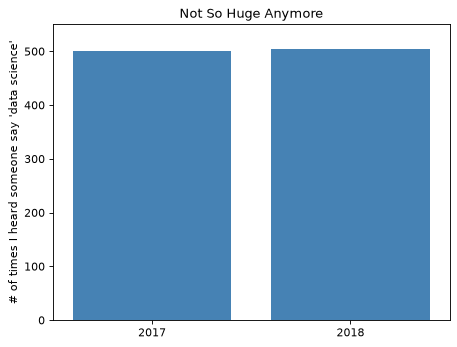

In [5]:
mentions = [500, 505]
years_short = [2017, 2018]

# --- Антипаттерн ---
plt.bar(years_short, mentions, 0.8, color="crimson")
plt.xticks(years_short)
plt.ylabel("# of times I heard someone say 'data science'")
plt.ticklabel_format(useOffset=False)
plt.axis([2016.5, 2018.5, 499, 506])          # ⚠️ обрезанная ось Y
plt.title("Look at the 'Huge' Increase!")

fpath = os.path.join(FIG_DIR, "viz_misleading_y_axis.png")
plt.savefig(fpath, dpi=80, bbox_inches="tight")
plt.gca().clear()
display(Image(filename=fpath))

# --- Корректный вариант ---
plt.bar(years_short, mentions, 0.8, color="steelblue")
plt.xticks(years_short)
plt.ylabel("# of times I heard someone say 'data science'")
plt.ticklabel_format(useOffset=False)
plt.axis([2016.5, 2018.5, 0, 550])            # ✅
plt.title("Not So Huge Anymore")

fpath = os.path.join(FIG_DIR, "viz_non_misleading_y_axis.png")
plt.savefig(fpath, dpi=80, bbox_inches="tight")
plt.gca().clear()
display(Image(filename=fpath))


### 3.5. Несколько серий + легенда — bias-variance tradeoff

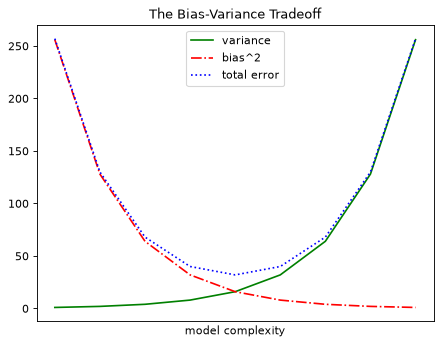

In [6]:
variance     = [1, 2, 4, 8, 16, 32, 64, 128, 256]
bias_squared = [256, 128, 64, 32, 16, 8, 4, 2, 1]
total_error  = [x + y for x, y in zip(variance, bias_squared)]
xs = [i for i, _ in enumerate(variance)]

plt.plot(xs, variance,     "g-",  label="variance")
plt.plot(xs, bias_squared, "r-.", label="bias^2")
plt.plot(xs, total_error,  "b:",  label="total error")
plt.legend(loc=9)
plt.xlabel("model complexity")
plt.xticks([])
plt.title("The Bias-Variance Tradeoff")

fpath = os.path.join(FIG_DIR, "viz_line_chart.png")
plt.savefig(fpath, dpi=80, bbox_inches="tight")
plt.gca().clear()
display(Image(filename=fpath))


### 3.6. Scatter с подписями точек — Friends vs Minutes

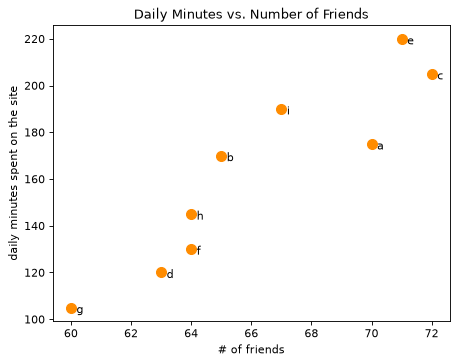

In [7]:
friends = [70, 65, 72, 63, 71, 64, 60, 64, 67]
minutes = [175, 170, 205, 120, 220, 130, 105, 145, 190]
labels  = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i']

plt.scatter(friends, minutes, color="darkorange", s=80)
for label, friend_count, minute_count in zip(labels, friends, minutes):
    plt.annotate(
        label,
        xy=(friend_count, minute_count),
        xytext=(5, -5),
        textcoords="offset points",
        fontsize=10,
    )
plt.title("Daily Minutes vs. Number of Friends")
plt.xlabel("# of friends")
plt.ylabel("daily minutes spent on the site")

fpath = os.path.join(FIG_DIR, "viz_scatterplot.png")
plt.savefig(fpath, dpi=80, bbox_inches="tight")
plt.gca().clear()
display(Image(filename=fpath))


### 3.7. Сравнимость осей (критично для scatter)

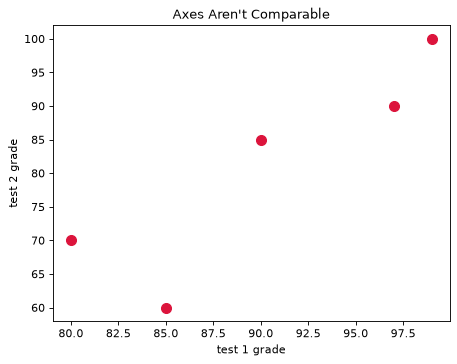

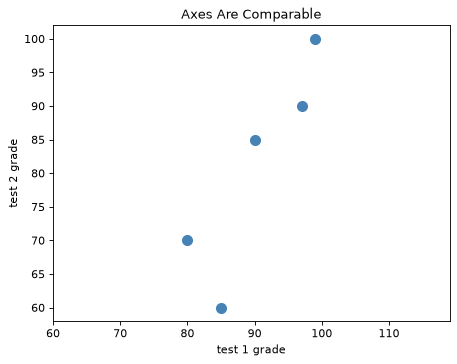

In [8]:
test_1_grades = [99, 90, 85, 97, 80]
test_2_grades = [100, 85, 60, 90, 70]

# --- Несравнимые оси ---
plt.scatter(test_1_grades, test_2_grades, color="crimson", s=80)
plt.title("Axes Aren't Comparable")
plt.xlabel("test 1 grade")
plt.ylabel("test 2 grade")
fpath = os.path.join(FIG_DIR, "viz_scatterplot_axes_not_comparable.png")
plt.savefig(fpath, dpi=80, bbox_inches="tight")
plt.gca().clear()
display(Image(filename=fpath))

# --- Сравнимые оси ---
plt.scatter(test_1_grades, test_2_grades, color="steelblue", s=80)
plt.title("Axes Are Comparable")
plt.axis("equal")
plt.xlabel("test 1 grade")
plt.ylabel("test 2 grade")
fpath = os.path.join(FIG_DIR, "viz_scatterplot_axes_comparable.png")
plt.savefig(fpath, dpi=80, bbox_inches="tight")
plt.gca().clear()
display(Image(filename=fpath))


## Глава 4. Линейная алгебра

Минимальный набор для ML: вектор, матрица, dot product, distance. В книге код лежит в `scratch/linear_algebra.py` и переиспользуется в следующих главах. Здесь дублируем локально.


### 4.1. Вектор и примеры

In [6]:
Vector = List[float]

# Вектор — упорядоченный список чисел фиксированной длины.
height_weight_age = [70, 170, 40]        # дюймы, фунты, годы
grades = [95, 80, 75, 62]                # 4 экзамена

print(f"height_weight_age = {height_weight_age}")
print(f"grades            = {grades}")
print(f"len(grades) = {len(grades)}, type = {type(grades)}")


height_weight_age = [70, 170, 40]
grades            = [95, 80, 75, 62]
len(grades) = 4, type = <class 'list'>


### 4.2. Поэлементные операции: add / subtract / scalar_multiply

In [7]:
def add(v: Vector, w: Vector) -> Vector:
    assert len(v) == len(w), "vectors must be the same length"
    return [v_i + w_i for v_i, w_i in zip(v, w)]


def subtract(v: Vector, w: Vector) -> Vector:
    assert len(v) == len(w), "vectors must be the same length"
    return [v_i - w_i for v_i, w_i in zip(v, w)]


def scalar_multiply(c: float, v: Vector) -> Vector:
    return [c * v_i for v_i in v]


# Демонстрация
print(f"add([1,2,3], [4,5,6])         = {add([1, 2, 3], [4, 5, 6])}")
print(f"subtract([5,7,9], [4,5,6])    = {subtract([5, 7, 9], [4, 5, 6])}")
print(f"scalar_multiply(2, [1,2,3])   = {scalar_multiply(2, [1, 2, 3])}")

assert add([1, 2, 3], [4, 5, 6]) == [5, 7, 9]
assert subtract([5, 7, 9], [4, 5, 6]) == [1, 2, 3]
assert scalar_multiply(2, [1, 2, 3]) == [2, 4, 6]
print("[OK] 4.2")


add([1,2,3], [4,5,6])         = [5, 7, 9]
subtract([5,7,9], [4,5,6])    = [1, 2, 3]
scalar_multiply(2, [1,2,3])   = [2, 4, 6]
[OK] 4.2


### 4.3. Покомпонентная сумма и среднее

In [8]:
def vector_sum(vectors: List[Vector]) -> Vector:
    assert vectors, "no vectors provided!"
    num_elements = len(vectors[0])
    assert all(len(v) == num_elements for v in vectors), "different sizes!"
    return [sum(vector[i] for vector in vectors)
            for i in range(num_elements)]


def vector_mean(vectors: List[Vector]) -> Vector:
    n = len(vectors)
    return scalar_multiply(1 / n, vector_sum(vectors))


print(f"vector_sum([[1,2],[3,4],[5,6],[7,8]]) = {vector_sum([[1, 2], [3, 4], [5, 6], [7, 8]])}")
print(f"vector_mean([[1,2],[3,4],[5,6]])      = {vector_mean([[1, 2], [3, 4], [5, 6]])}")

assert vector_sum([[1, 2], [3, 4], [5, 6], [7, 8]]) == [16, 20]
assert vector_mean([[1, 2], [3, 4], [5, 6]]) == [3, 4]
print("[OK] 4.3")


vector_sum([[1,2],[3,4],[5,6],[7,8]]) = [16, 20]
vector_mean([[1,2],[3,4],[5,6]])      = [3.0, 4.0]
[OK] 4.3


### 4.4. Скалярное произведение (dot product) — ГЛАВНАЯ операция

In [9]:
def dot(v: Vector, w: Vector) -> float:
    assert len(v) == len(w), "vectors must be same length"
    return sum(v_i * w_i for v_i, w_i in zip(v, w))


def sum_of_squares(v: Vector) -> float:
    return dot(v, v)


print(f"dot([1,2,3], [4,5,6])      = {dot([1, 2, 3], [4, 5, 6])}")   # 32
print(f"sum_of_squares([1,2,3])    = {sum_of_squares([1, 2, 3])}")   # 14

assert dot([1, 2, 3], [4, 5, 6]) == 32
assert sum_of_squares([1, 2, 3]) == 14
print("[OK] 4.4 dot product")


dot([1,2,3], [4,5,6])      = 32
sum_of_squares([1,2,3])    = 14
[OK] 4.4 dot product


### 4.5. Магнитуда и евклидово расстояние

In [10]:
def magnitude(v: Vector) -> float:
    return math.sqrt(sum_of_squares(v))


def distance(v: Vector, w: Vector) -> float:
    return magnitude(subtract(v, w))


print(f"magnitude([3,4])           = {magnitude([3, 4])}")                    # 5
print(f"distance([1,2], [4,6])     = {distance([1, 2], [4, 6]):.4f}")         # 5.0

assert magnitude([3, 4]) == 5
assert abs(distance([1, 2], [4, 6]) - 5.0) < 1e-9
print("[OK] 4.5 magnitude/distance")


magnitude([3,4])           = 5.0
distance([1,2], [4,6])     = 5.0000
[OK] 4.5 magnitude/distance


### 4.6. Матрицы

In [11]:
Matrix = List[List[float]]

A = [[1, 2, 3],                         # 2 строки × 3 столбца
     [4, 5, 6]]

B = [[1, 2],                            # 3 строки × 2 столбца
     [3, 4],
     [5, 6]]


def shape(A: Matrix) -> Tuple[int, int]:
    num_rows = len(A)
    num_cols = len(A[0]) if A else 0
    return num_rows, num_cols


def get_row(A: Matrix, i: int) -> Vector:
    return A[i]


def get_column(A: Matrix, j: int) -> Vector:
    return [A_i[j] for A_i in A]


print(f"shape(A) = {shape(A)}")             # (2, 3)
print(f"shape(B) = {shape(B)}")             # (3, 2)
print(f"get_row(A, 0)    = {get_row(A, 0)}")
print(f"get_column(A, 1) = {get_column(A, 1)}")

assert shape([[1, 2, 3], [4, 5, 6]]) == (2, 3)
print("[OK] 4.6 matrix basics")


shape(A) = (2, 3)
shape(B) = (3, 2)
get_row(A, 0)    = [1, 2, 3]
get_column(A, 1) = [2, 5]
[OK] 4.6 matrix basics


### 4.7. Конструкторы: `make_matrix`, `identity_matrix`

In [12]:
def make_matrix(num_rows: int,
                num_cols: int,
                entry_fn: Callable[[int, int], float]) -> Matrix:
    return [[entry_fn(i, j) for j in range(num_cols)]
            for i in range(num_rows)]


def identity_matrix(n: int) -> Matrix:
    return make_matrix(n, n, lambda i, j: 1 if i == j else 0)


I5 = identity_matrix(5)
print("Единичная матрица 5×5:")
for row in I5:
    print(" ", row)

assert identity_matrix(5) == [
    [1, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 1],
]
print("[OK] 4.7 identity_matrix")


Единичная матрица 5×5:
  [1, 0, 0, 0, 0]
  [0, 1, 0, 0, 0]
  [0, 0, 1, 0, 0]
  [0, 0, 0, 1, 0]
  [0, 0, 0, 0, 1]
[OK] 4.7 identity_matrix


### 4.8. Практический кейс: матрица дружбы (взвешенный граф)

In [13]:
friend_matrix = [
    [0, 1, 1, 0, 0, 0, 0, 0, 0, 0],  # user 0
    [1, 0, 1, 1, 0, 0, 0, 0, 0, 0],  # user 1
    [1, 1, 0, 1, 0, 0, 0, 0, 0, 0],  # user 2
    [0, 1, 1, 0, 1, 0, 0, 0, 0, 0],  # user 3
    [0, 0, 0, 1, 0, 1, 0, 0, 0, 0],  # user 4
    [0, 0, 0, 0, 1, 0, 1, 1, 0, 0],  # user 5
    [0, 0, 0, 0, 0, 1, 0, 0, 1, 0],  # user 6
    [0, 0, 0, 0, 0, 1, 0, 0, 1, 0],  # user 7
    [0, 0, 0, 0, 0, 0, 1, 1, 0, 1],  # user 8
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],  # user 9
]

# Список друзей пользователя 5 — просто фильтр по строке
friends_of_five = [i for i, is_friend in enumerate(friend_matrix[5])
                   if is_friend]

print(f"Друзья user 5: {friends_of_five}")
print(f"Друзья user 0: {[i for i, is_friend in enumerate(friend_matrix[0]) if is_friend]}")
print(f"Друзья user 9: {[i for i, is_friend in enumerate(friend_matrix[9]) if is_friend]}")

assert friend_matrix[0][2] == 1, "0 и 2 — друзья"
assert friend_matrix[0][8] == 0, "0 и 8 — не друзья"
assert friends_of_five == [4, 6, 7]
print("[OK] 4.8 friend matrix")


Друзья user 5: [4, 6, 7]
Друзья user 0: [1, 2]
Друзья user 9: [8]
[OK] 4.8 friend matrix


## Глава 5. Статистика

Использует `sum_of_squares` и `dot` из главы 4 — они переиспользуются. В этом и смысл «библиотеки `scratch`»: набор примитивов, поверх которого строятся ML-алгоритмы дальше.


### 5.1. Данные: число друзей и ежедневное время на сайте

In [14]:
num_friends = [100.0, 49, 41, 40, 25, 21, 21, 19, 19, 18,
               18, 16, 15, 15, 15, 15, 14, 14, 13, 13,
               13, 13, 12, 12, 11, 10, 10, 10, 10, 10,
               10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
               9, 9, 9, 9, 9, 9, 9, 9, 9, 9,
               9, 9, 9, 9, 9, 9, 9, 9, 8, 8,
               8, 8, 8, 8, 8, 8, 8, 8, 8, 8,
               8, 7, 7, 7, 7, 7, 7, 7, 7, 7,
               7, 7, 7, 7, 7, 7, 6, 6, 6, 6,
               6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
               6, 6, 6, 6, 6, 6, 6, 6, 5, 5,
               5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
               5, 5, 5, 5, 5, 4, 4, 4, 4, 4,
               4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
               4, 4, 4, 4, 4, 3, 3, 3, 3, 3,
               3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
               3, 3, 3, 3, 3, 2, 2, 2, 2, 2,
               2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
               2, 2, 1, 1, 1, 1, 1, 1, 1, 1,
               1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
               1, 1, 1, 1]

assert len(num_friends) == 204
print(f"n = {len(num_friends)}, min = {min(num_friends)}, max = {max(num_friends)}")


n = 204, min = 1, max = 100.0


In [15]:
daily_minutes = [
    1, 68.77, 51.25, 52.08, 38.36, 44.54, 57.13, 51.4, 41.42, 31.22,
    34.76, 54.01, 38.79, 47.59, 49.1, 27.66, 41.03, 36.73, 48.65, 28.12,
    46.62, 35.57, 32.98, 35.0, 26.07, 23.77, 39.73, 40.57, 31.65, 31.21,
    36.32, 20.45, 21.93, 26.02, 27.34, 23.49, 46.94, 30.5, 33.8, 24.23,
    21.4, 27.94, 32.24, 40.57, 25.07, 19.42, 22.39, 18.42, 46.96, 23.72,
    26.41, 26.97, 36.76, 40.32, 35.02, 29.47, 30.2, 31.0, 38.11, 38.18,
    36.31, 21.03, 30.86, 36.07, 28.66, 29.08, 37.28, 15.28, 24.17, 22.31,
    30.17, 25.53, 19.85, 35.37, 44.6, 17.23, 13.47, 26.33, 35.02, 32.09,
    24.81, 19.33, 28.77, 24.26, 31.98, 25.73, 24.86, 16.28, 34.51, 15.23,
    39.72, 40.8, 26.06, 35.76, 34.76, 16.13, 44.04, 18.03, 19.65, 32.62,
    35.59, 39.43, 14.18, 35.24, 40.13, 41.82, 35.45, 36.07, 43.67, 24.61,
    20.9, 21.9, 18.79, 27.61, 27.21, 26.61, 29.77, 20.59, 27.53, 13.82,
    33.2, 25.0, 33.1, 36.65, 18.63, 14.87, 22.2, 36.81, 25.53, 24.62,
    26.25, 18.21, 28.08, 19.42, 29.79, 32.8, 35.99, 28.32, 27.79, 35.88,
    29.06, 36.28, 14.1, 36.63, 37.49, 26.9, 18.58, 38.48, 24.48, 18.95,
    33.55, 14.24, 29.04, 32.51, 25.63, 22.22, 19.0, 32.73, 15.16, 13.9,
    27.2, 32.01, 29.27, 33.0, 13.74, 20.42, 27.32, 18.23, 35.35, 28.48,
    9.08, 24.62, 20.12, 35.26, 19.92, 31.02, 16.49, 12.16, 30.7, 31.22,
    34.65, 13.13, 27.51, 33.2, 31.57, 14.1, 33.42, 17.44, 10.12, 24.42,
    9.82, 23.39, 30.93, 15.03, 21.67, 31.09, 33.29, 22.61, 26.89, 23.48,
    8.38, 27.81, 32.35, 23.84,
]

daily_hours = [dm / 60 for dm in daily_minutes]
print(f"daily_minutes: n={len(daily_minutes)}, mean={sum(daily_minutes)/len(daily_minutes):.2f}")
print(f"daily_hours:   n={len(daily_hours)}, mean={sum(daily_hours)/len(daily_hours):.4f}")


daily_minutes: n=204, mean=29.03
daily_hours:   n=204, mean=0.4838


### 5.1.1. Гистограмма распределения числа друзей

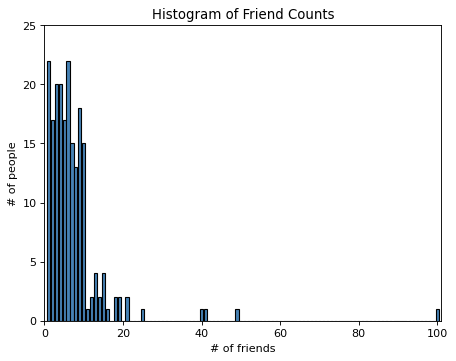

In [16]:
friend_counts = Counter(num_friends)
xs = range(101)
ys = [friend_counts[x] for x in xs]
plt.bar(xs, ys, color="steelblue", edgecolor="black")
plt.axis([0, 101, 0, 25])
plt.title("Histogram of Friend Counts")
plt.xlabel("# of friends")
plt.ylabel("# of people")

fpath = os.path.join(FIG_DIR, "viz_hist_friend_counts.png")
plt.savefig(fpath, dpi=80, bbox_inches="tight")
plt.gca().clear()
display(Image(filename=fpath))


### 5.2. Меры центральной тенденции

In [17]:
def mean(xs: List[float]) -> float:
    return sum(xs) / len(xs)


def _median_odd(xs: List[float]) -> float:
    return sorted(xs)[len(xs) // 2]


def _median_even(xs: List[float]) -> float:
    sorted_xs = sorted(xs)
    hi_midpoint = len(xs) // 2
    return (sorted_xs[hi_midpoint - 1] + sorted_xs[hi_midpoint]) / 2


def median(v: List[float]) -> float:
    return _median_even(v) if len(v) % 2 == 0 else _median_odd(v)


def quantile(xs: List[float], p: float) -> float:
    p_index = int(p * len(xs))
    return sorted(xs)[p_index]


def mode(x: List[float]) -> List[float]:
    counts = Counter(x)
    max_count = max(counts.values())
    return [x_i for x_i, count in counts.items() if count == max_count]


# Реальные вызовы
m = mean(num_friends)
med = median(num_friends)
q10, q25, q75, q90 = (quantile(num_friends, p) for p in (0.10, 0.25, 0.75, 0.90))
modes = mode(num_friends)

print(f"mean(num_friends)    = {m:.4f}")
print(f"median(num_friends)  = {med}")
print(f"quantile(.10/.25/.75/.90) = {q10}/{q25}/{q75}/{q90}")
print(f"mode(num_friends)    = {modes}")

assert 7.3333 < mean(num_friends) < 7.3334
assert median(num_friends) == 6
assert quantile(num_friends, 0.10) == 1
assert set(mode(num_friends)) == {1, 6}
print("[OK] 5.2 central tendency")


mean(num_friends)    = 7.3333
median(num_friends)  = 6.0
quantile(.10/.25/.75/.90) = 1/3/9/13
mode(num_friends)    = [6, 1]
[OK] 5.2 central tendency


### 5.3. Меры разброса (dispersion)

In [18]:
def data_range(xs: List[float]) -> float:
    return max(xs) - min(xs)


def de_mean(xs: List[float]) -> List[float]:
    x_bar = mean(xs)
    return [x - x_bar for x in xs]


def variance(xs: List[float]) -> float:
    assert len(xs) >= 2, "variance requires at least two elements"
    n = len(xs)
    deviations = de_mean(xs)
    return sum_of_squares(deviations) / (n - 1)


def standard_deviation(xs: List[float]) -> float:
    return math.sqrt(variance(xs))


def interquartile_range(xs: List[float]) -> float:
    return quantile(xs, 0.75) - quantile(xs, 0.25)


# Вызовы
r = data_range(num_friends)
v = variance(num_friends)
sd = standard_deviation(num_friends)
iqr = interquartile_range(num_friends)

print(f"data_range(num_friends)         = {r}")
print(f"variance(num_friends)           = {v:.4f}")
print(f"standard_deviation(num_friends) = {sd:.4f}")
print(f"interquartile_range(num_friends)= {iqr}")

assert data_range(num_friends) == 99
assert 81.54 < variance(num_friends) < 81.55
assert 9.02 < standard_deviation(num_friends) < 9.04
assert interquartile_range(num_friends) == 6
print("[OK] 5.3 dispersion")


data_range(num_friends)         = 99.0
variance(num_friends)           = 81.5435
standard_deviation(num_friends) = 9.0301
interquartile_range(num_friends)= 6
[OK] 5.3 dispersion


### 5.4. Ковариация и корреляция

In [19]:
def covariance(xs: List[float], ys: List[float]) -> float:
    assert len(xs) == len(ys), "xs and ys must have same number of elements"
    return dot(de_mean(xs), de_mean(ys)) / (len(xs) - 1)


def correlation(xs: List[float], ys: List[float]) -> float:
    stdev_x = standard_deviation(xs)
    stdev_y = standard_deviation(ys)
    if stdev_x > 0 and stdev_y > 0:
        return covariance(xs, ys) / stdev_x / stdev_y
    else:
        return 0


# Вызовы
cov_minutes = covariance(num_friends, daily_minutes)
cov_hours   = covariance(num_friends, daily_hours)
corr_minutes = correlation(num_friends, daily_minutes)
corr_hours   = correlation(num_friends, daily_hours)

print(f"covariance(num_friends, daily_minutes) = {cov_minutes:.4f}")
print(f"covariance(num_friends, daily_hours)   = {cov_hours:.6f}")
print(f"correlation(num_friends, daily_minutes)= {corr_minutes:.4f}")
print(f"correlation(num_friends, daily_hours)  = {corr_hours:.4f}")

assert 22.42 < covariance(num_friends, daily_minutes) < 22.43
assert 0.24 < correlation(num_friends, daily_minutes) < 0.25
print("[OK] 5.4 covariance/correlation")


covariance(num_friends, daily_minutes) = 22.4254
covariance(num_friends, daily_hours)   = 0.373757
correlation(num_friends, daily_minutes)= 0.2474
correlation(num_friends, daily_hours)  = 0.2474
[OK] 5.4 covariance/correlation


### 5.5. ⚠️ Чувствительность корреляции к выбросам

Один юзер с 100 друзьями — выброс. Если его убрать, корреляция **прыгает с 0.24 до 0.57**!

Типичный DS-урок: «средние» и «корреляции» сильно зависят от хвостов.

In [20]:
outlier = num_friends.index(100)
num_friends_good   = [x for i, x in enumerate(num_friends)   if i != outlier]
daily_minutes_good = [x for i, x in enumerate(daily_minutes) if i != outlier]
daily_hours_good   = [dm / 60 for dm in daily_minutes_good]

corr_good_min = correlation(num_friends_good, daily_minutes_good)
corr_good_hr  = correlation(num_friends_good, daily_hours_good)

print(f"С выбросом:    correlation = {corr_minutes:.4f}")
print(f"Без выброса:   correlation = {corr_good_min:.4f}  ← почти в 2.5 раза выше!")

assert 0.57 < correlation(num_friends_good, daily_minutes_good) < 0.58
print("[OK] 5.5 outlier sensitivity")


С выбросом:    correlation = 0.2474
Без выброса:   correlation = 0.5737  ← почти в 2.5 раза выше!
[OK] 5.5 outlier sensitivity


## Итог глав 3-5

- **Визуализация** (matplotlib) — основной инструмент «первого взгляда» на данные.
- **Линейная алгебра** (векторы, матрицы, dot) — фундамент всех ML-моделей.
- **Статистика** (mean, variance, correlation) — фундамент любого EDA.

**Дальше в книге:**
- гл. 6 — теория вероятностей
- гл. 7 — гипотезы и статистические выводы
- гл. 8 — градиентный спуск
- гл. 9 — получение данных (scraping, API, файлы)
- гл. 10 — работа с данными (pandas-подобный слой)
- гл. 11 — машинное обучение
